## Using a synthetic regression dataset:
### a) Implement linear regression using MLE.
### b) Implement MAP estimation assuming a Gaussian prior on parameters.
### c) Compare parameter estimates and predictive uncertainty.

MLE parameters: [1.50742783 3.85674284]
MAP parameters: [1.4875129  3.80821159]


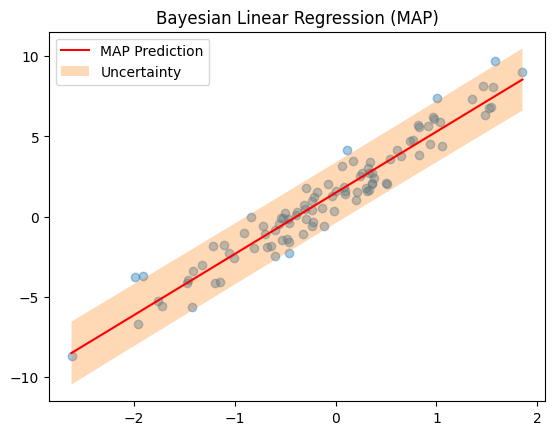

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

n = 100
X = np.random.randn(n, 1)
true_w = 4.0
true_b = 1.5

noise = np.random.normal(0, 1.0, n)
y = true_w * X.flatten() + true_b + noise

# Design matrix
X_design = np.c_[np.ones(n), X]

w_mle = np.linalg.inv(X_design.T @ X_design) @ X_design.T @ y
print("MLE parameters:", w_mle)

lambda_reg = 1.0  # regularization strength
I = np.eye(X_design.shape[1])

w_map = np.linalg.inv(
    X_design.T @ X_design + lambda_reg * I
) @ X_design.T @ y

print("MAP parameters:", w_map)

residuals = y - X_design @ w_mle
sigma2 = np.var(residuals)

Sigma_w = sigma2 * np.linalg.inv(X_design.T @ X_design + lambda_reg * I)


X_test = np.linspace(X.min(), X.max(), 100).reshape(-1,1)
X_test_design = np.c_[np.ones(len(X_test)), X_test]

y_mean = X_test_design @ w_map
y_var = np.sum(X_test_design @ Sigma_w * X_test_design, axis=1) + sigma2
y_std = np.sqrt(y_var)

plt.scatter(X, y, alpha=0.4)
plt.plot(X_test, y_mean, color="red", label="MAP Prediction")
plt.fill_between(
    X_test.flatten(),
    y_mean - 2*y_std,
    y_mean + 2*y_std,
    alpha=0.3,
    label="Uncertainty"
)
plt.legend()
plt.title("Bayesian Linear Regression (MAP)")
plt.show()


Maximum Likelihood Estimation provides point estimates of regression parameters based solely on observed data. Maximum A Posteriori estimation incorporates prior beliefs through a Gaussian prior, resulting in regularized parameter estimates. MAP estimates exhibit reduced variance and improved stability, and Bayesian regression further enables predictive uncertainty quantification, which MLE lacks.